In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import imageio
import glob
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio
from rasterio.mask import mask
import os
import collections
from matplotlib.colors import ListedColormap
from datetime import datetime, timedelta
from rasterio.transform import xy, rowcol

In [56]:
dataset_names = [
    "Crop Types",
    "Main Crop Emergence",
    "Main Crop Duration"
]

cropland_type_dict = {
    1110: "Wheat",
    1120: "Barley",
    1130: "Maize",
    1140: "Rice",
    1150: "Other cereals",
    1210: "Fresh Vegetables",
    1220: "Dry Pulses",
    1310: "Potatoes",
    1320: "Sugar Beet",
    1410: "Sunflower",
    1420: "Soybeans",
    1430: "Rapeseed",
    1440: "Flax cotton and hemp",
    2100: "Grapes",
    2200: "Olives",
    2310: "Fruits",
    2320: "Nuts",
    3100: "Unclassified annual crop",
    3200: "Unclassified permanent crop",
    65535: "outside area",
}


In [33]:
dims_x_max, dims_y_max = 4000, 4000

def get_file_from_name(name):
    name_norm = name.replace(" ", "_")
    data_dir = os.path.join("data", name_norm, "**" , "*.tif")
    file = sorted(glob.glob(data_dir))[6]
    return file


def load_dataset_sample(name):
    with rasterio.open(get_file_from_name(name)) as src:
        data = src.read(1)
    return data
    
def get_mpl_cmap(name):
    with rasterio.open(get_file_from_name(name)) as src:
        geotiff_cmap = src.colormap(1)
    # Convert to 0–1 floats and preserve order
    colors = []
    for i in range(max(geotiff_cmap.keys()) + 1):
        r, g, b, a = geotiff_cmap[i]
        colors.append((r/255, g/255, b/255, a/255))

    return ListedColormap(colors)


def prep_copernicus_data(data, subsample=1):
    data = data[0:dims_x_max:subsample, 0:dims_y_max:subsample]
    quality_flag_mask = ((data >= 65526) & (data <=  65534))
    # The range between 65526 and 65534 indicates different types of issues during data collection, all of which indicate incomplete or unreliable data
    # TODO: check if some of them might still be useful!
    
    data[quality_flag_mask] = 0
    return data

Counter({np.uint16(0): 5441340, np.uint16(65535): 5099036, np.uint16(1110): 2111490, np.uint16(1430): 1606905, np.uint16(1120): 902009, np.uint16(1130): 389341, np.uint16(1150): 158749, np.uint16(1320): 131383, np.uint16(1220): 122643, np.uint16(1210): 14883, np.uint16(1310): 11226, np.uint16(2310): 5620, np.uint16(3100): 5082, np.uint16(1440): 165, np.uint16(1410): 128})
Counter({np.uint16(0): 5699611, np.uint16(65535): 5099036, np.uint16(22242): 213161, np.uint16(22283): 183464, np.uint16(22282): 164836, np.uint16(22248): 126620, np.uint16(22284): 122132, np.uint16(22246): 118538, np.uint16(22290): 101686, np.uint16(22262): 95338, np.uint16(22247): 95096, np.uint16(22266): 87907, np.uint16(22278): 87300, np.uint16(22275): 84550, np.uint16(22237): 82987, np.uint16(22270): 82337, np.uint16(22245): 81491, np.uint16(22243): 81377, np.uint16(22240): 77796, np.uint16(22280): 73476, np.uint16(22281): 70827, np.uint16(22244): 68208, np.uint16(22241): 67382, np.uint16(22258): 66496, np.uint16

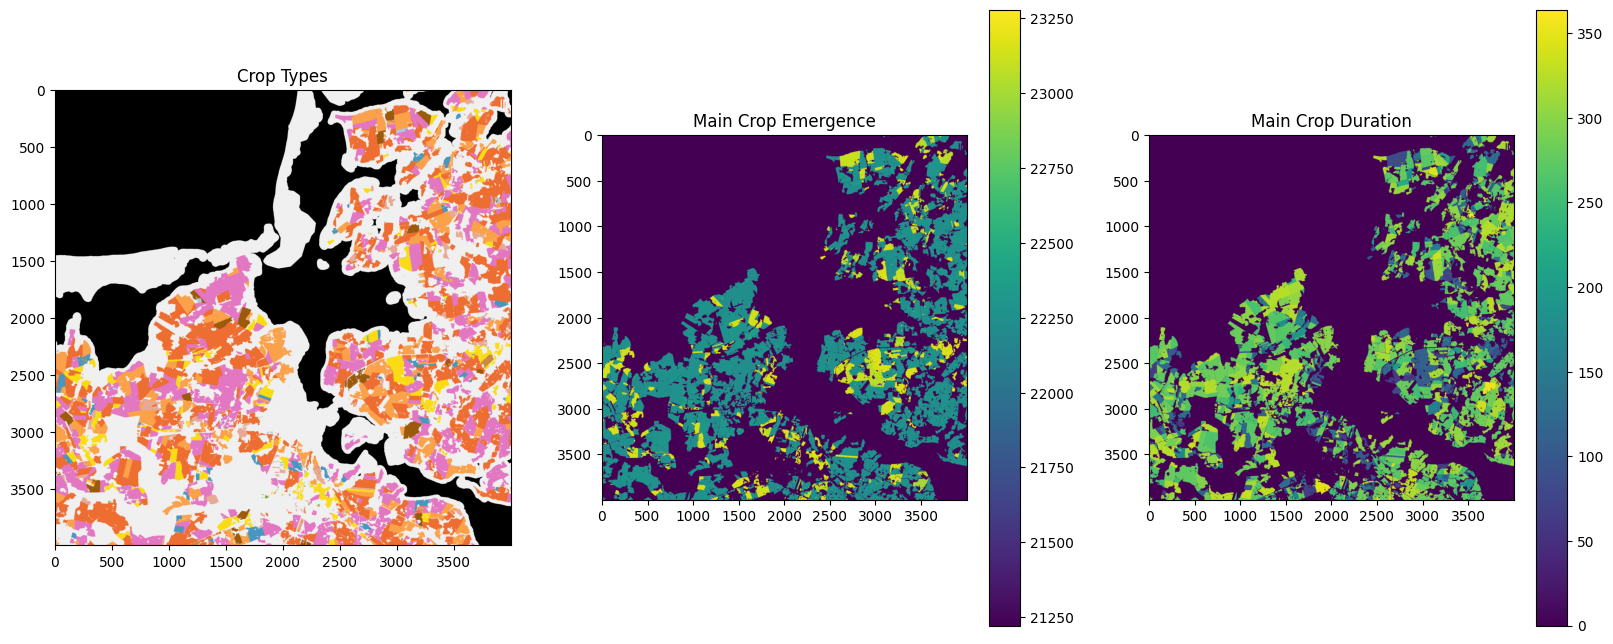

In [ ]:
emergence_default_val = 21222

subsample = 10
fig, axs = plt.subplots(1, 3, figsize=(20,8))

# crop types
dataset = dataset_names[0]
ax = axs[0]
crop_types = load_dataset_sample(dataset)
    
crop_types = prep_copernicus_data(crop_types)
# print(collections.Counter(crop_types.flatten()))
types_im = ax.imshow(crop_types, get_mpl_cmap(dataset))
ax.set_title(dataset)
    
dataset = dataset_names[1]
ax = axs[1]
crop_emergence = load_dataset_sample(dataset)
crop_emergence = prep_copernicus_data(crop_emergence)
# print(collections.Counter(crop_emergence.flatten()))
crop_emergence[(crop_emergence < 22000) | (crop_emergence > 24000)] = emergence_default_val

emerg_im = ax.imshow(crop_emergence)
ax.set_title(dataset)
plt.colorbar(emerg_im, ax=ax) 


    
dataset = dataset_names[2]
ax = axs[2]
crop_duration = load_dataset_sample(dataset)

crop_duration = prep_copernicus_data(crop_duration)

crop_duration[(crop_duration < 1) | (crop_duration > 365)] = 0
# print(collections.Counter(crop_duration.flatten()))
dur_im = ax.imshow(crop_duration)
ax.set_title(dataset)
plt.colorbar(dur_im, ax=ax) 


In [7]:
len(crop_emergence[crop_emergence > 22000])

5201353

In [8]:
len(crop_duration[crop_duration > 0])

5201353

In [9]:
# All annual crop types have class codes between 1100 (wheat) and 1440 (flax cotton and hemp). Also includes 3100 (Unclassified annual crop)
annual_crop_mask = ((crop_types > 1000) & (crop_types < 2000)) | (crop_types == 3100)

In [10]:
len(crop_types[annual_crop_mask])

5454004

In [11]:
diff_mask = annual_crop_mask & ~(crop_duration > 0)

In [12]:
collections.Counter(crop_types[diff_mask])

Counter({np.uint16(1430): 109492,
         np.uint16(1110): 67996,
         np.uint16(1120): 25497,
         np.uint16(1130): 14777,
         np.uint16(1150): 13603,
         np.uint16(1320): 8989,
         np.uint16(1210): 3987,
         np.uint16(1220): 3708,
         np.uint16(3100): 3014,
         np.uint16(1310): 1295,
         np.uint16(1440): 165,
         np.uint16(1410): 128})

In [13]:
crop_emergence2 = load_dataset_sample(dataset)
crop_emergence2 = crop_emergence2[::subsample, ::subsample]
collections.Counter(crop_emergence2[diff_mask])

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 4000

In [14]:
flat_color_dict = {}

all_vals = sorted(list(set(crop_types.flatten())))

for i in range(len(all_vals)):
    flat_color_dict[all_vals[i]] = i


In [15]:
def date_from_cop_fmt(date_code):
    year = 2000 + date_code // 1000 
    day_of_year = date_code % 1000
    dt = datetime(year,1,1) + timedelta(days=float(day_of_year)-1)
    return dt

In [16]:
crop_duration.max(axis=None)

np.uint16(364)

In [17]:
min_date = date_from_cop_fmt(crop_emergence[crop_emergence > emergence_default_val].min(axis=None))
max_date = date_from_cop_fmt(crop_emergence.max(axis=None)) + timedelta(days=float(crop_duration.max(axis=None)))
print(min_date, max_date)

2022-08-15 00:00:00 2024-10-05 00:00:00


In [18]:

yearly_data = []


cdi_files = sorted(glob.glob(os.path.join("combined_drought_indicator_2012-2025", "**", "*.tif")))


def date_from_filename(filename):
    date_str = filename.split("_")[3]
    date = datetime.strptime(date_str, "%Y%m%d")
    return date


def filter_cdi_file_dates(filenames):
    out_arr = []
    global_min, global_max = min_date, max_date
    for f in filenames:
        file_start_date = date_from_filename(os.path.basename(f))
        file_end_date = file_start_date + timedelta(days=10)
        if min_date <= file_start_date <= max_date or min_date <= file_end_date <= max_date:
            global_min = min(global_min, file_start_date)
            global_max = max(global_max, file_end_date)
            out_arr.append(f)
    
    return out_arr, global_min, global_max
        
cdi_files, cdi_min_date, cdi_max_date = filter_cdi_file_dates(cdi_files)

In [58]:
with rasterio.open(cdi_files[0]) as src:
    cdi_crs = src.read_crs()
    cdi_dims = src.read(1).shape
    cdi_transform = src.transform
    
with rasterio.open(get_file_from_name(dataset_names[0])) as src:
    cropland_crs = src.read_crs()
    cropland_transform = src.transform
    pixel_width, pixel_height = src.res

In [36]:
cdi_array = np.zeros(((cdi_max_date-cdi_min_date).days, dims_x_max, dims_y_max),dtype=bool)

In [37]:

import rasterio
from rasterio.warp import reproject, Resampling

for f in cdi_files:
    with rasterio.open(f) as src:
        raw_data = src.read(1)
    

        # Prepare an empty array for the reprojected B
        cdi_data = np.empty_like(crop_types, dtype=raw_data.dtype)

        # Perform reprojection
        reproject(
            source=raw_data,
            destination=cdi_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=cropland_transform,
            dst_crs=cropland_crs,
            dst_width=dims_x_max,
            dst_height=dims_y_max,
            resampling=Resampling.nearest  # TODO: or bilinear, cubic, etc.
        )

    
    file_start_date = date_from_filename(os.path.basename(f))
       
    
    print(f)        
    drought_mask = (cdi_data == 2) | (cdi_data == 3)
    x_offset = (file_start_date-cdi_min_date).days
    cdi_array[x_offset:x_offset+10]= drought_mask
    

combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20220811_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20220821_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20220901_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20220911_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20220921_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20221001_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20221011_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20221021_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_20221221_t/cdinx_m_edo_20221101_t_400_z04.tif
combined_drought_indicator_2012-2025/cdinx_m_edo_20220101_202212

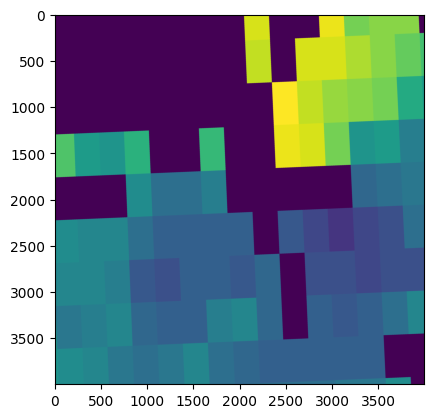

In [38]:
plt.imshow(cdi_array.sum(axis=0))

In [45]:
xarr, yarr = np.where(crop_duration > 0)


In [ ]:
crop_n_days_tot = {}
crop_n_days_drought = {}
crop_n_pixels = {}

for idx, (x, y) in enumerate(zip(xarr, yarr)):
    if idx % 100000 == 0:
        print(idx)
    start_date = date_from_cop_fmt(crop_emergence[x,y])
    duration = crop_duration[x,y]
    ctype = crop_types[x,y]
    
    date_offset = (start_date-cdi_min_date).days
    
    if ctype not in crop_n_days_tot:
        crop_n_days_tot[ctype] = np.int64(0)
        crop_n_days_drought[ctype] = np.int64(0)
        crop_n_pixels[ctype] = np.int64(0)
    
    crop_n_days_tot[ctype] += duration
    drought_days = cdi_array[date_offset:date_offset+duration, x, y]
    crop_n_days_drought[ctype] += drought_days.sum()
    crop_n_pixels[ctype] += 1


0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000


In [66]:
crop_data = pd.DataFrame(columns= ["type", "area", "per_affected"])

for crop_type in crop_n_days_drought.keys():
    n_drought_days = crop_n_days_drought[crop_type]
    n_total_days = crop_n_days_tot[crop_type]
    crop_name = cropland_type_dict[crop_type]
    crop_area = (crop_n_pixels[crop_type] * 100 /1e6).round(2)
    
    drought_affect = (100*n_drought_days/n_total_days).round(2)
    crop_data.loc[len(crop_data)] = [crop_name, crop_area, drought_affect]
    print(f"{crop_name}: {crop_area}km2, {drought_affect}% drought affected")
    
    
    
    

Barley: 87.65km2, 28.38% drought affected
Rapeseed: 149.74km2, 29.67% drought affected
Other cereals: 14.51km2, 31.57% drought affected
Wheat: 204.35km2, 32.3% drought affected
Fresh Vegetables: 1.09km2, 47.62% drought affected
Maize: 37.46km2, 47.75% drought affected
Sugar Beet: 12.24km2, 46.8% drought affected
Dry Pulses: 11.89km2, 75.4% drought affected
Unclassified annual crop: 0.21km2, 40.83% drought affected
Potatoes: 0.99km2, 58.69% drought affected


In [69]:
crop_data

,type,area,per_affected
3,Wheat,204.35,32.30
1,Rapeseed,149.74,29.67
0,Barley,87.65,28.38
5,Maize,37.46,47.75
2,Other cereals,14.51,31.57
6,Sugar Beet,12.24,46.80
7,Dry Pulses,11.89,75.40
4,Fresh Vegetables,1.09,47.62
9,Potatoes,0.99,58.69
8,Unclassified annual crop,0.21,40.83


In [68]:
crop_data = crop_data.sort_values(by="area", ascending=False)

In [ ]:
fig, ax = plt.subplots(1, 2)

ax[0].bars(crop_data["area"])

In [55]:
crop_n_days_tot

{np.uint16(1120): np.int64(220906658),
 np.uint16(1430): np.int64(455975553),
 np.uint16(1150): np.int64(38986908),
 np.uint16(1110): np.int64(541564276),
 np.uint16(1210): np.int64(1425433),
 np.uint16(1130): np.int64(45891524),
 np.uint16(1320): np.int64(19988537),
 np.uint16(1220): np.int64(10848214),
 np.uint16(3100): np.int64(357172),
 np.uint16(1310): np.int64(922736)}

In [ ]:


for dir in :
    if dir.endswith(".zip"):
        continue
    
    masked_frames = []

    files = sorted(glob.glob(os.path.join(dir, "*")))
    files = [file for file in files if file.endswith(".tif")]
    for i, file in enumerate(files):
        with rasterio.open(file) as src:
            
            im_masked, transform = mask(
                    src,
                    eu_mask.geometry,
                    all_touched=True,
                    crop=True,
                    pad=True, # TODO: recheck the parametrization on this function call!
                    nodata=-1 # we pretend that any pixel that is not in the EU mask is covered by water
                    ) # remove coordinate transformation info
        
        im_masked = im_masked[0]
        im_masked = drought_index_mapper[im_masked]

        im_masked = (im_masked > 1).astype(float)
        
        cur_date = date_from_filename(os.path.basename(file))
        if (i + 1) < len(files):
            next_date = date_from_filename(os.path.basename(files[i+1]))
        else: 
            next_date = datetime.fromisocalendar(cur_date.year + 1, 1, 1)               
        delta_t = next_date - cur_date
        
        im_masked *= delta_t.days


        
        
        masked_frames.append(im_masked)

    frames_ar = np.array(masked_frames)
    print(frames_ar[:,600,1000])
    
    frames_ar = frames_ar.sum(axis=0).astype(np.float64)
    frames_ar *= 100 / 365.0 # go from total number of 
    
    yearly_data = frames_ar
    fig, ax = plt.subplots()
    im = ax.imshow(frames_ar)

    fig.colorbar(im, ax=ax)
    plt.show()
    break
    

SyntaxError: invalid syntax (3080660015.py, line 11)